In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [31]:
apple = yf.download("AAPL", start="2019-01-01", end="2024-01-01")

apple.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503731,37.724594,36.627408,36.784150,148158800
2019-01-03,33.768089,34.606413,33.722966,34.193187,365248800
2019-01-04,35.209610,35.278483,34.150426,34.323790,234428400
2019-01-07,35.131248,35.344988,34.649153,35.314113,219111200
2019-01-08,35.800953,36.055064,35.271361,35.518344,164101200


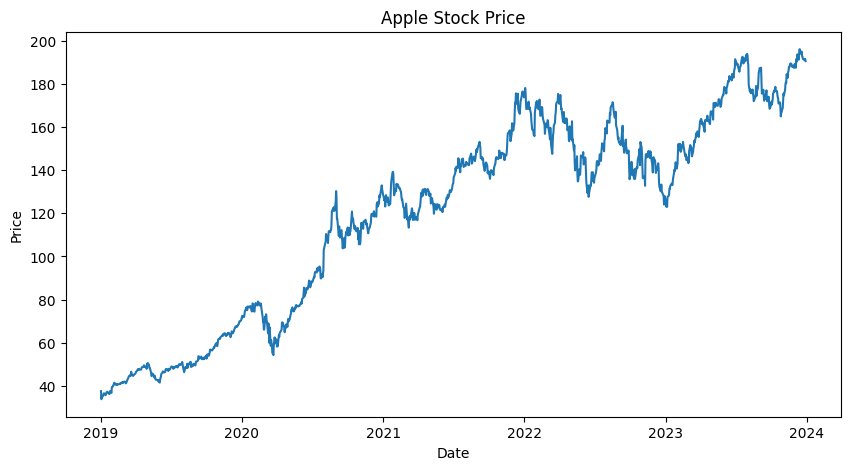

In [32]:
plt.figure(figsize=(10,5))
plt.plot(apple["Close"])
plt.title("Apple Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [33]:
apple["Return"] = apple["Close"].pct_change()

apple.head()

Price,Close,High,Low,Open,Volume,Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2019-01-02,37.503731,37.724594,36.627408,36.784150,148158800,NaN
2019-01-03,33.768089,34.606413,33.722966,34.193187,365248800,-0.099607
2019-01-04,35.209610,35.278483,34.150426,34.323790,234428400,0.042689
2019-01-07,35.131248,35.344988,34.649153,35.314113,219111200,-0.002226
2019-01-08,35.800953,36.055064,35.271361,35.518344,164101200,0.019063


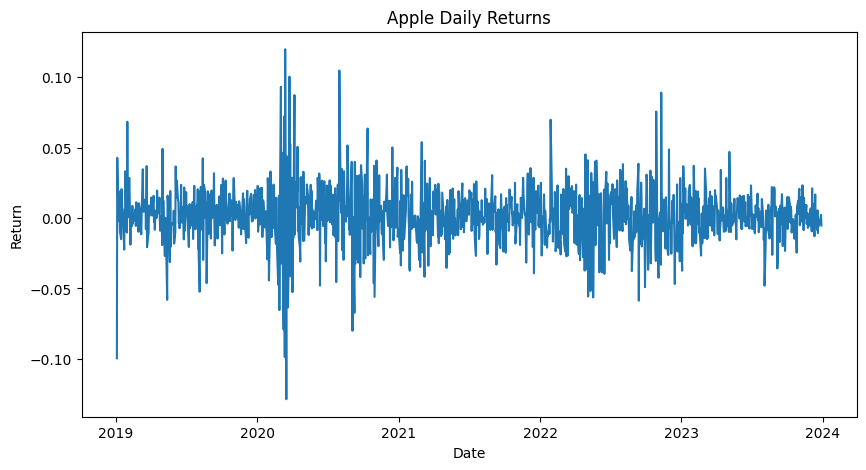

In [34]:
plt.figure(figsize=(10,5))
plt.plot(apple["Return"])
plt.title("Apple Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

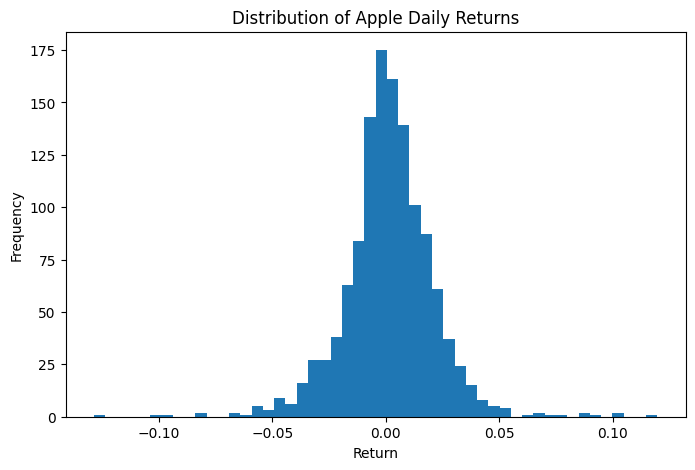

In [35]:
plt.figure(figsize=(8,5))
plt.hist(apple["Return"].dropna(), bins=50)
plt.title("Distribution of Apple Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

In [36]:
volatility = apple["Return"].std()

print("Daily Volatility:", volatility)

Daily Volatility: 0.020305853759844537


In [37]:
stocks = yf.download(["AAPL","MSFT","GOOGL","TSLA","SPY","GLD","TLT"], 
                     start="2019-01-01", 
                     end="2024-01-01")["Close"]
stocks.head()

[*********************100%***********************]  7 of 7 completed


Ticker,AAPL,GLD,GOOGL,MSFT,SPY,TLT,TSLA
Date,,,,,,,
2019-01-02,37.503731,121.330002,52.338547,94.397148,224.995316,100.225250,20.674667
2019-01-03,33.768089,122.430000,50.888996,90.924469,219.626312,101.365768,20.024000
2019-01-04,35.209610,121.440002,53.499275,95.153313,226.982834,100.192398,21.179333
2019-01-07,35.131248,121.860001,53.392578,95.274658,228.772522,99.897041,22.330667
2019-01-08,35.800953,121.529999,53.861542,95.965454,230.921951,99.634483,22.356667


<Figure size 1200x600 with 0 Axes>

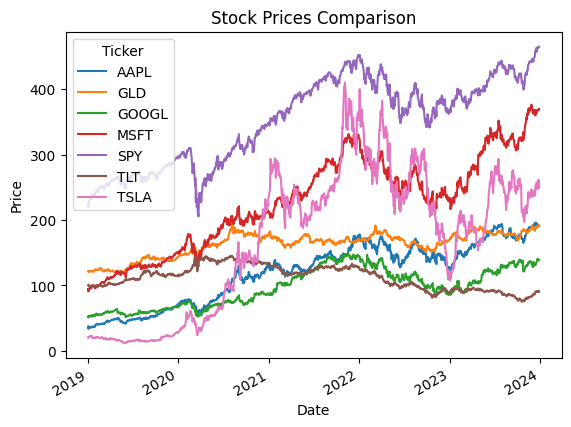

In [38]:
plt.figure(figsize=(12,6))
stocks.plot()
plt.title("Stock Prices Comparison")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [39]:
returns = stocks.pct_change()

returns.head()

Ticker,AAPL,GLD,GOOGL,MSFT,SPY,TLT,TSLA
Date,,,,,,,
2019-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,-0.099607,0.009066,-0.027696,-0.036788,-0.023863,0.011380,-0.031472
2019-01-04,0.042689,-0.008086,0.051294,0.046509,0.033496,-0.011576,0.057697
2019-01-07,-0.002226,0.003458,-0.001994,0.001275,0.007885,-0.002948,0.054361
2019-01-08,0.019063,-0.002708,0.008783,0.007251,0.009395,-0.002628,0.001164


In [40]:
correlation = returns.corr()

print(correlation)

Ticker      AAPL       GLD     GOOGL      MSFT       SPY       TLT      TSLA
Ticker                                                                      
AAPL    1.000000  0.085232  0.674939  0.758621  0.804537 -0.134466  0.488406
GLD     0.085232  1.000000  0.081277  0.090819  0.107689  0.310320  0.077337
GOOGL   0.674939  0.081277  1.000000  0.758999  0.762075 -0.101079  0.408303
MSFT    0.758621  0.090819  0.758999  1.000000  0.824587 -0.120977  0.453118
SPY     0.804537  0.107689  0.762075  0.824587  1.000000 -0.194594  0.497529
TLT    -0.134466  0.310320 -0.101079 -0.120977 -0.194594  1.000000 -0.047305
TSLA    0.488406  0.077337  0.408303  0.453118  0.497529 -0.047305  1.000000


In [41]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


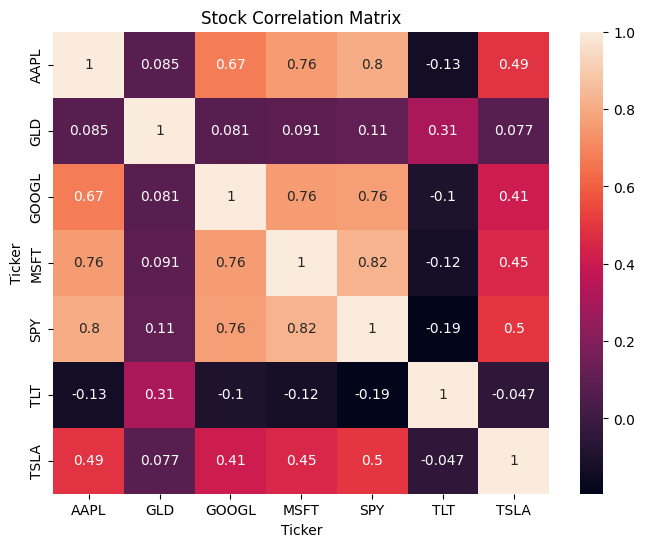

In [42]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True)
plt.title("Stock Correlation Matrix")
plt.show()

In [43]:


portfolio_return = np.sum(returns.mean() * weights) * 252
portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov()*252, weights)))

print("Portfolio Return:", portfolio_return)
print("Portfolio Volatility:", portfolio_volatility)

Portfolio Return: 0.2655946165405593
Portfolio Volatility: 0.22676419749715035


In [44]:
num_ports = 1000

all_weights = []
returns_arr = []
volatility_arr = []

In [45]:
for i in range(num_ports):

    weights = np.random.random(len(stocks.columns))
    weights = weights / np.sum(weights)

    all_weights.append(weights)

    port_return = np.sum(returns.mean() * weights) * 252
    returns_arr.append(port_return)

    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov()*252, weights)))
    volatility_arr.append(port_vol)

In [46]:
returns_arr = np.array(returns_arr)
volatility_arr = np.array(volatility_arr)

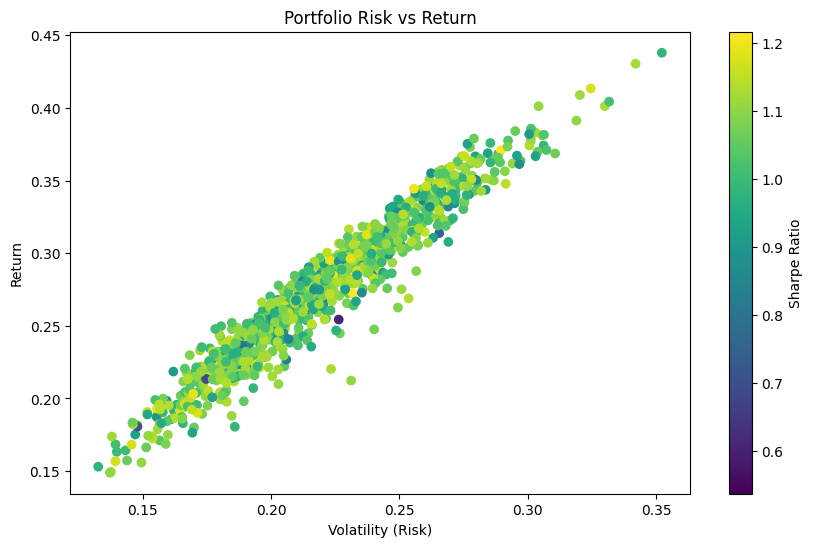

In [47]:
plt.figure(figsize=(10,6))
plt.scatter(volatility_arr, returns_arr, c=sharpe_ratio)
plt.xlabel("Volatility (Risk)")
plt.ylabel("Return")
plt.title("Portfolio Risk vs Return")
plt.colorbar(label="Sharpe Ratio")
plt.show()

In [48]:
risk_free_rate = 0.04   # 4% annual treasury yield

sharpe_ratio = (returns_arr - risk_free_rate) / volatility_arr

In [49]:
max_sharpe_index = sharpe_ratio.argmax()

best_return = returns_arr[max_sharpe_index]
best_volatility = volatility_arr[max_sharpe_index]
best_weights = all_weights[max_sharpe_index]

print("Best Portfolio Return:", best_return)
print("Best Portfolio Volatility:", best_volatility)
print("Best Portfolio Weights:", best_weights)

Best Portfolio Return: 0.3789515746663322
Best Portfolio Volatility: 0.27896528010280147
Best Portfolio Weights: [0.22775702 0.21854783 0.02333403 0.2250185  0.01168909 0.02416194
 0.26949159]


In [50]:
def value_at_risk(returns, confidence=0.95):
    
    return np.percentile(returns, (1-confidence)*100)

In [51]:
portfolio_returns = returns.dot(best_weights)

var_95 = value_at_risk(portfolio_returns)

print("95% Value at Risk:", var_95)

95% Value at Risk: nan


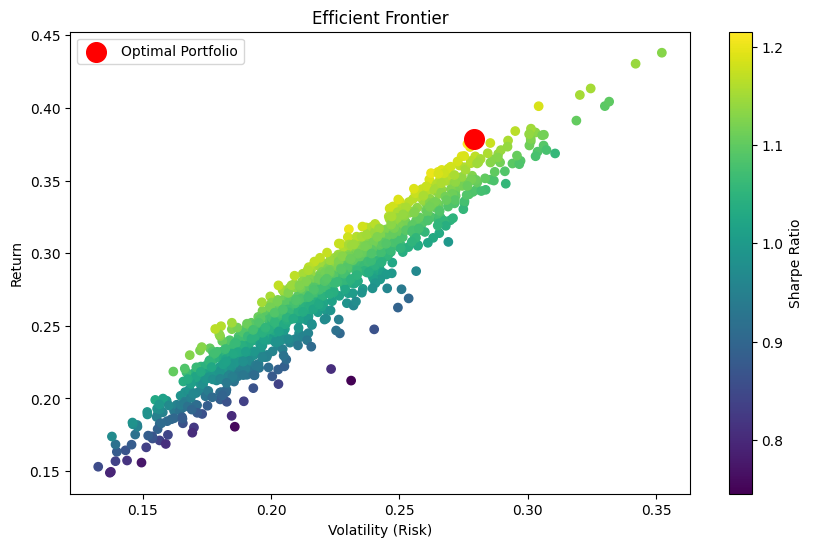

In [52]:
plt.figure(figsize=(10,6))
plt.scatter(volatility_arr, returns_arr, c=sharpe_ratio)
plt.colorbar(label="Sharpe Ratio")

plt.scatter(best_volatility, best_return, color="red", s=200, label="Optimal Portfolio")

plt.xlabel("Volatility (Risk)")
plt.ylabel("Return")
plt.title("Efficient Frontier")

plt.legend()

plt.savefig("../images/efficient_frontier.png")

plt.show()

In [53]:
stocks.columns

Index(['AAPL', 'GLD', 'GOOGL', 'MSFT', 'SPY', 'TLT', 'TSLA'], dtype='str', name='Ticker')

In [54]:
portfolio = pd.DataFrame({
    "Stock": stocks.columns,
    "Weight": best_weights
})

portfolio


,Stock,Weight
0,AAPL,0.227757
1,GLD,0.218548
2,GOOGL,0.023334
3,MSFT,0.225019
4,SPY,0.011689
5,TLT,0.024162
6,TSLA,0.269492


In [55]:
portfolio = portfolio.sort_values(by="Weight", ascending=False)

portfolio

,Stock,Weight
6,TSLA,0.269492
0,AAPL,0.227757
3,MSFT,0.225019
1,GLD,0.218548
5,TLT,0.024162
2,GOOGL,0.023334
4,SPY,0.011689


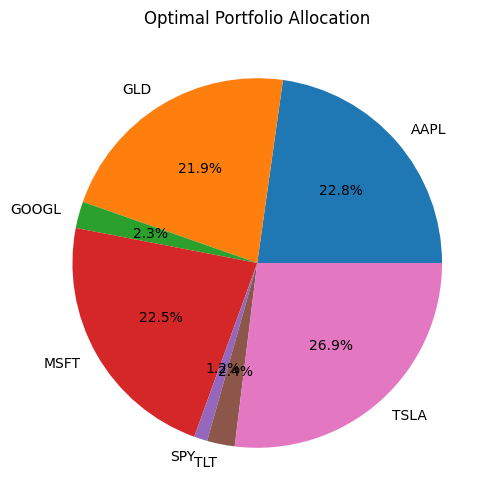

In [56]:
plt.figure(figsize=(6,6))
plt.pie(best_weights, labels=stocks.columns, autopct="%1.1f%%")
plt.title("Optimal Portfolio Allocation")
plt.show()

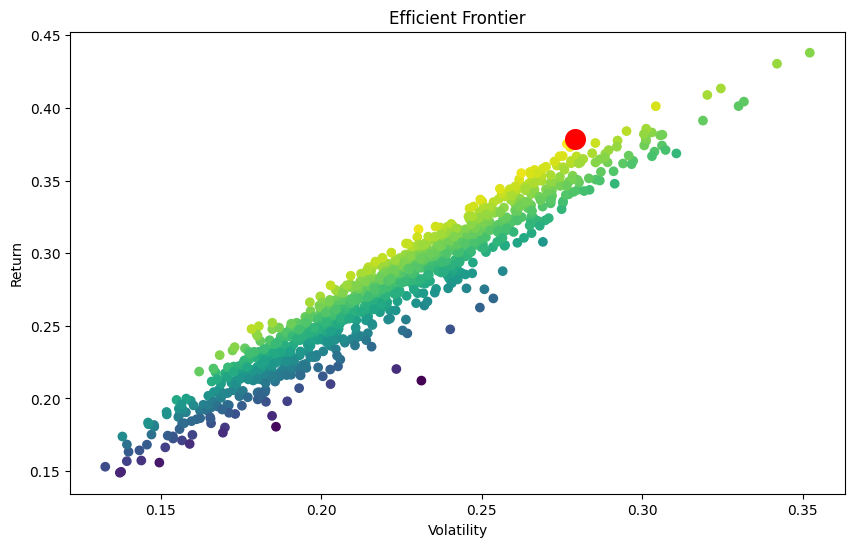

In [57]:
plt.figure(figsize=(10,6))
plt.scatter(volatility_arr, returns_arr, c=sharpe_ratio)
plt.scatter(best_volatility, best_return, color="red", s=200)

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier")

plt.savefig("efficient_frontier.png")
plt.show()